# Train ResNet18 on OrganAMNIST

In [1]:

from pathlib import Path
import os
import shutil
import sys

ROOT = Path.cwd().parents[1].resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

os.environ.setdefault(
    "PYTHON_JULIAPKG_PROJECT",
    str(Path.home() / "Documents" / "dev" / "MAGENetRunner" / "python_utils"),
)
os.environ.setdefault("PYTHON_JULIAPKG_OFFLINE", "yes")
julia_exe = shutil.which("julia")
if julia_exe is not None:
    os.environ.setdefault("PYTHON_JULIAPKG_EXE", julia_exe)


In [2]:

import torch

from python_utils.medmnist_resnet_baseline import (
    DatasetConfig,
    build_model,
    clean_checkpoints,
    evaluate_loader,
    load_checkpoint,
    plot_training_curves,
    prepare_experiment,
    print_metrics,
    select_best_checkpoint,
    train_model,
)


/home/camilo/Documents/dev/MAGENetRunner/.CondaPkg/env/lib/python3.12/site-packages/juliacall/__init__.py:61: UserWarning: torch was imported before juliacall. This may cause a segfault. To avoid this, import juliacall before importing torch. For updates, see https://github.com/pytorch/pytorch/issues/78829.
  warnings.warn(


Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [3]:

SEED = 123
TRAIN_BATCH_SIZE = 128
EVAL_BATCH_SIZE = 512
EPOCHS = 30
LR = 1e-4
WEIGHT_DECAY = 1e-4
USE_CLASS_WEIGHTS = True
RESIZE_TO = 224

CONFIG = DatasetConfig(
    dataset_name="OrganAMNIST",
    train_file=str(ROOT / "datasets_pickle" / "OrganAMNIST_64_train.jld2"),
    val_file=str(ROOT / "datasets_pickle" / "OrganAMNIST_64_val.jld2"),
    test_file=str(ROOT / "datasets_pickle" / "OrganAMNIST_64_test.jld2"),
    num_classes=11,
    batch_size=TRAIN_BATCH_SIZE,
    val_batch_size=EVAL_BATCH_SIZE,
    epochs=EPOCHS,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
    use_class_weights=USE_CLASS_WEIGHTS,
    seed=SEED,
    resize_to=RESIZE_TO,
    output_dir="ORGANAMNIST/NN_baselines",
    experiment_name="resnet18_OrganAMNIST",
    backbone_name="resnet18",
    nd=1,
    pretrained_weights="default",
)

CONFIG


DatasetConfig(dataset_name='OrganAMNIST', train_file='/home/camilo/Documents/dev/MAGENetRunner/datasets_pickle/OrganAMNIST_64_train.jld2', val_file='/home/camilo/Documents/dev/MAGENetRunner/datasets_pickle/OrganAMNIST_64_val.jld2', test_file='/home/camilo/Documents/dev/MAGENetRunner/datasets_pickle/OrganAMNIST_64_test.jld2', num_classes=11, batch_size=128, val_batch_size=512, epochs=30, lr=0.0001, weight_decay=0.0001, use_class_weights=True, seed=123, resize_to=224, output_dir='ORGANAMNIST/NN_baselines', experiment_name='resnet18_OrganAMNIST', backbone_name='resnet18', nd=1, pretrained_weights='default')

In [4]:

CONTEXT = prepare_experiment(CONFIG)
MODEL = build_model(
    CONFIG.backbone_name,
    CONFIG.num_classes,
    pretrained_weights=CONFIG.pretrained_weights,
).to(CONTEXT.device)
OPTIMIZER = torch.optim.AdamW(
    MODEL.parameters(),
    lr=CONFIG.lr,
    weight_decay=CONFIG.weight_decay,
)


Reading /home/camilo/Documents/dev/MAGENetRunner/datasets_pickle/OrganAMNIST_64_train.jld2
Reading /home/camilo/Documents/dev/MAGENetRunner/datasets_pickle/OrganAMNIST_64_val.jld2
Reading /home/camilo/Documents/dev/MAGENetRunner/datasets_pickle/OrganAMNIST_64_test.jld2
TORCH DEVICE cuda
N CPUS 16
CWD : /home/camilo/Documents/dev/MAGENetRunner/ORGANAMNIST/NN_baselines
Metrics file: /home/camilo/Documents/dev/MAGENetRunner/ORGANAMNIST/NN_baselines/resnet18_OrganAMNIST/cnn_metrics_resnet.csv
TRAIN DATASET SIZE : 34561
VAL DATASET SIZE : 6491
TEST DATASET SIZE : 17778
normalization mean: [0.46701300144195557, 0.46701300144195557, 0.46701300144195557] | std: [0.28526946902275085, 0.28526946902275085, 0.28526946902275085]
class weights: [1.606292963027954, 2.260366201400757, 2.3153345584869385, 2.1315529346466064, 0.7928107976913452, 0.8231357336044312, 0.50971919298172, 0.801711916923523, 0.7996714115142822, 1.0365915298461914, 0.8823108673095703]


In [5]:

METRICS_DF = train_model(CONTEXT, MODEL, OPTIMIZER)
METRICS_DF.tail()


Epoch [0/30], Train Loss: 2.5820, Train ACC: 0.0447, Train BACC: 0.0977
Epoch [0/30], Val Loss: 2.5858, Val ACC: 0.0401, Val BACC: 0.0637
Checkpoint saved at epoch 1 to /home/camilo/Documents/dev/MAGENetRunner/ORGANAMNIST/NN_baselines/resnet18_OrganAMNIST/DLmodels_resnet/checkpoints/1.pth
Epoch [1/30], Train Loss: 0.2155, Train ACC: 0.9343, Train BACC: 0.9334
Epoch [1/30], Val Loss: 0.0263, Val ACC: 0.9928, Val BACC: 0.9939
Checkpoint saved at epoch 2 to /home/camilo/Documents/dev/MAGENetRunner/ORGANAMNIST/NN_baselines/resnet18_OrganAMNIST/DLmodels_resnet/checkpoints/2.pth
Epoch [2/30], Train Loss: 0.0358, Train ACC: 0.9903, Train BACC: 0.9896
Epoch [2/30], Val Loss: 0.0353, Val ACC: 0.9894, Val BACC: 0.9908
Checkpoint saved at epoch 3 to /home/camilo/Documents/dev/MAGENetRunner/ORGANAMNIST/NN_baselines/resnet18_OrganAMNIST/DLmodels_resnet/checkpoints/3.pth
Epoch [3/30], Train Loss: 0.0179, Train ACC: 0.9955, Train BACC: 0.9951
Epoch [3/30], Val Loss: 0.0327, Val ACC: 0.9889, Val BACC:

,epoch,loss,val_loss,accuracy,val_accuracy,balanced_accuracy,val_balanced_accuracy
26,26,0.002312,0.017502,0.999421,0.991989,0.999426,0.993750
27,27,0.002249,0.008761,0.999595,0.996457,0.999617,0.996323
28,28,0.005003,0.049554,0.999016,0.985056,0.998638,0.986584
29,29,0.005689,0.034349,0.998582,0.989832,0.998464,0.990469
30,30,0.003193,0.021244,0.999219,0.993838,0.999123,0.994043


In [6]:

BEST_VAL_ACC_CKPT, METRICS_DF = select_best_checkpoint(CONTEXT, "val_accuracy")
BEST_VAL_ACC_MODEL = build_model(
    CONFIG.backbone_name,
    CONFIG.num_classes,
    pretrained_weights=CONFIG.pretrained_weights,
).to(CONTEXT.device)
load_checkpoint(BEST_VAL_ACC_MODEL, BEST_VAL_ACC_CKPT, CONTEXT.device)
VAL_ACC_METRICS, _, _, _ = evaluate_loader(
    BEST_VAL_ACC_MODEL,
    CONTEXT.val_dataloader,
    CONTEXT.device,
    CONFIG.num_classes,
)
TEST_ACC_METRICS, _, _, _ = evaluate_loader(
    BEST_VAL_ACC_MODEL,
    CONTEXT.test_dataloader,
    CONTEXT.device,
    CONFIG.num_classes,
)
print_metrics("Best Val-ACC checkpoint | Validation", VAL_ACC_METRICS)
print_metrics("Best Val-ACC checkpoint | Test", TEST_ACC_METRICS)


Best val_accuracy: epoch 13
Checkpoint to read: /home/camilo/Documents/dev/MAGENetRunner/ORGANAMNIST/NN_baselines/resnet18_OrganAMNIST/DLmodels_resnet/checkpoints/13.pth
Loaded checkpoint /home/camilo/Documents/dev/MAGENetRunner/ORGANAMNIST/NN_baselines/resnet18_OrganAMNIST/DLmodels_resnet/checkpoints/13.pth
Best Val-ACC checkpoint | Validation Accuracy: 0.997
Best Val-ACC checkpoint | Validation Balanced Accuracy: 0.997
Best Val-ACC checkpoint | Validation AUC: 1.000
Best Val-ACC checkpoint | Test Accuracy: 0.963
Best Val-ACC checkpoint | Test Balanced Accuracy: 0.955
Best Val-ACC checkpoint | Test AUC: 0.996


In [7]:

BEST_VAL_BACC_CKPT, METRICS_DF = select_best_checkpoint(CONTEXT, "val_balanced_accuracy")
BEST_VAL_BACC_MODEL = build_model(
    CONFIG.backbone_name,
    CONFIG.num_classes,
    pretrained_weights=CONFIG.pretrained_weights,
).to(CONTEXT.device)
load_checkpoint(BEST_VAL_BACC_MODEL, BEST_VAL_BACC_CKPT, CONTEXT.device)
VAL_BACC_METRICS, _, _, _ = evaluate_loader(
    BEST_VAL_BACC_MODEL,
    CONTEXT.val_dataloader,
    CONTEXT.device,
    CONFIG.num_classes,
)
TEST_BACC_METRICS, _, _, _ = evaluate_loader(
    BEST_VAL_BACC_MODEL,
    CONTEXT.test_dataloader,
    CONTEXT.device,
    CONFIG.num_classes,
)
print_metrics("Best Val-BACC checkpoint | Validation", VAL_BACC_METRICS)
print_metrics("Best Val-BACC checkpoint | Test", TEST_BACC_METRICS)


Best val_balanced_accuracy: epoch 8
Checkpoint to read: /home/camilo/Documents/dev/MAGENetRunner/ORGANAMNIST/NN_baselines/resnet18_OrganAMNIST/DLmodels_resnet/checkpoints/8.pth
Loaded checkpoint /home/camilo/Documents/dev/MAGENetRunner/ORGANAMNIST/NN_baselines/resnet18_OrganAMNIST/DLmodels_resnet/checkpoints/8.pth
Best Val-BACC checkpoint | Validation Accuracy: 0.996
Best Val-BACC checkpoint | Validation Balanced Accuracy: 0.997
Best Val-BACC checkpoint | Validation AUC: 1.000
Best Val-BACC checkpoint | Test Accuracy: 0.961
Best Val-BACC checkpoint | Test Balanced Accuracy: 0.958
Best Val-BACC checkpoint | Test AUC: 0.998


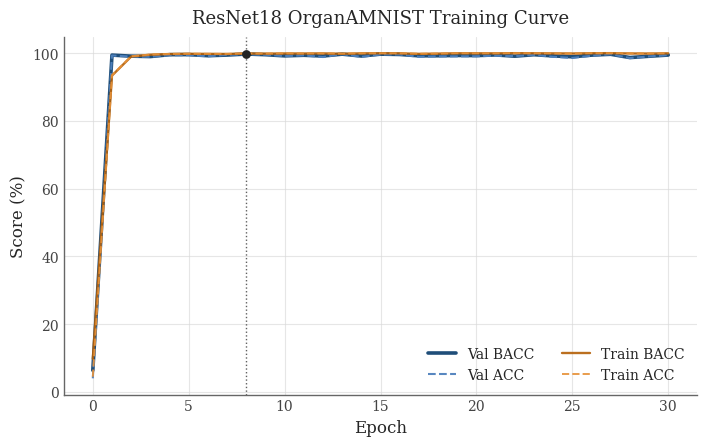

Saved plot to /home/camilo/Documents/dev/MAGENetRunner/ORGANAMNIST/NN_baselines/resnet18_OrganAMNIST/training_curve_resnet18.png
Deleting: /home/camilo/Documents/dev/MAGENetRunner/ORGANAMNIST/NN_baselines/resnet18_OrganAMNIST/DLmodels_resnet/checkpoints/11.pth
Deleting: /home/camilo/Documents/dev/MAGENetRunner/ORGANAMNIST/NN_baselines/resnet18_OrganAMNIST/DLmodels_resnet/checkpoints/5.pth
Deleting: /home/camilo/Documents/dev/MAGENetRunner/ORGANAMNIST/NN_baselines/resnet18_OrganAMNIST/DLmodels_resnet/checkpoints/17.pth
Deleting: /home/camilo/Documents/dev/MAGENetRunner/ORGANAMNIST/NN_baselines/resnet18_OrganAMNIST/DLmodels_resnet/checkpoints/19.pth
Deleting: /home/camilo/Documents/dev/MAGENetRunner/ORGANAMNIST/NN_baselines/resnet18_OrganAMNIST/DLmodels_resnet/checkpoints/3.pth
Deleting: /home/camilo/Documents/dev/MAGENetRunner/ORGANAMNIST/NN_baselines/resnet18_OrganAMNIST/DLmodels_resnet/checkpoints/6.pth
Deleting: /home/camilo/Documents/dev/MAGENetRunner/ORGANAMNIST/NN_baselines/resnet

In [8]:

PLOT_PATH = CONTEXT.folder / "training_curve_resnet18.png"
plot_training_curves(
    METRICS_DF,
    title="ResNet18 OrganAMNIST Training Curve",
    output_path=PLOT_PATH,
)
clean_checkpoints(CONTEXT.checkpoint_dir, {BEST_VAL_ACC_CKPT, BEST_VAL_BACC_CKPT})
